# Vehicle Classification Project
Compare Custom CNN, MobileNetV2, and EfficientNetB0. Select the best model, then apply SHAP and Grad-CAM to the best model.

In [1]:
# File handling
import os
import shutil

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers, models

# Transfer learning models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

2026-06-25 07:28:18.307334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782372498.334662     224 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782372498.343918     224 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782372498.366260     224 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782372498.366289     224 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782372498.366292     224 computation_placer.cc:177] computation placer alr

In [2]:
# Define project-wide configuration parameters
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# Create a clean version of the dataset by validating all images,
# converting them to RGB format, and saving them into a new directory.
# This removes corrupted/incompatible files and ensures consistent
# image formatting before training the deep learning models.

SOURCE = "/kaggle/input/datasets/mohamedmaher5/vehicle-classification/Vehicles"
CLEAN = "/kaggle/working/clean_dataset"

os.makedirs(CLEAN, exist_ok=True)

copied = 0
skipped = 0

for cls in os.listdir(SOURCE):

    src_cls = os.path.join(SOURCE, cls)

    if not os.path.isdir(src_cls):
        continue

    dst_cls = os.path.join(CLEAN, cls)

    os.makedirs(dst_cls, exist_ok=True)

    for file in os.listdir(src_cls):

        src_file = os.path.join(src_cls, file)

        try:

            img = Image.open(src_file)

            img = img.convert("RGB")

            save_path = os.path.join(dst_cls, file)

            img.save(save_path, "JPEG")

            copied += 1

        except Exception as e:

            skipped += 1

            print("Skipped:", src_file)

print("Copied:", copied)
print("Skipped:", skipped)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Copied: 5590
Skipped: 0


In [4]:
DATASET_PATH = "/kaggle/working/clean_dataset"

print(os.listdir(DATASET_PATH))

['Cars', 'Planes', 'Ships', 'Motorcycles', 'Auto Rickshaws', 'Bikes', 'Trains']


In [5]:
# Load the image dataset, automatically create training and validation splits,
# then further divide the validation set into separate validation and test datasets
# for model training, tuning, and final performance evaluation.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_full = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_full)
test_ds = val_full.take(val_batches // 2)
val_ds = val_full.skip(val_batches // 2)

class_names = train_ds.class_names
print(class_names)


Found 5588 files belonging to 7 classes.
Using 4471 files for training.


I0000 00:00:1782372558.114976     224 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782372558.120323     224 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5588 files belonging to 7 classes.
Using 1117 files for validation.
['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [6]:
# Optimize data loading performance and apply preprocessing techniques
# including data augmentation and pixel value normalization to improve
# model generalization and training efficiency.
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.prefetch(AUTOTUNE)
val_ds=val_ds.prefetch(AUTOTUNE)
test_ds=test_ds.prefetch(AUTOTUNE)

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

normalization=layers.Rescaling(1./255)
print(normalization)


<Rescaling name=rescaling, built=False>


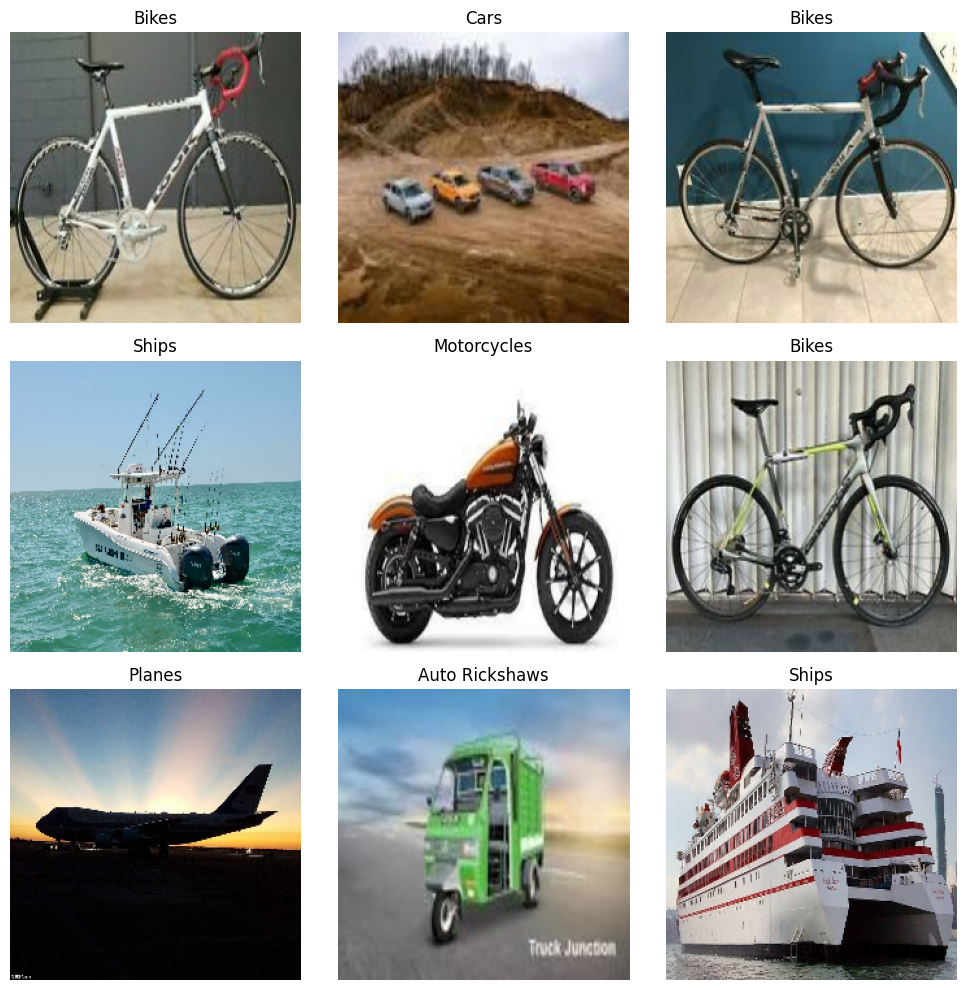

In [7]:

# Sample images
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.pdf')
plt.show()


In [8]:
# Define training callbacks to prevent overfitting, adjust learning rate,
# and automatically save the best-performing model during training.
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully")

Callbacks created successfully


In [9]:
# Build, compile, and train a custom CNN model for multi-class vehicle image classification.
# The model learns hierarchical image features through convolutional layers and uses
# regularization techniques to improve generalization and reduce overfitting.
# Custom CNN
cnn=models.Sequential([
    data_augmentation,
    normalization,
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names),activation='softmax')
])
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn_history=cnn_history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
               
    ]
)

print(
    "Training stopped automatically to avoid overfitting."
)

Epoch 1/50


I0000 00:00:1782372566.580229     291 cuda_dnn.cc:529] Loaded cuDNN version 91002


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2124 - loss: 1.9918
Epoch 1: val_accuracy improved from None to 0.38743, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.2856 - loss: 1.7837 - val_accuracy: 0.3874 - val_loss: 1.6148 - learning_rate: 0.0010
Epoch 2/50
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4643 - loss: 1.4415
Epoch 2: val_accuracy improved from 0.38743 to 0.53927, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.4970 - loss: 1.3717 - val_accuracy: 0.5393 - val_loss: 1.3114 - learning_rate: 0.0010
Epoch 3/50
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5281 - loss: 1.2451
Epoch 3: val_accuracy improved from 0.53927 to 0.66318, saving model to /kaggle/working/best_model.keras

Epoch 3: finish

In [10]:
# Implement transfer learning using MobileNetV2 as a pretrained feature extractor.
# The pretrained layers are frozen to retain learned ImageNet features, while a
# custom classification head is trained for vehicle image classification.
# MobileNetV2
base=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable=False

mobilenet=models.Sequential([
    data_augmentation,
    normalization,
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names),activation='softmax')
])

mobilenet.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
mobile_history=mobile_history = mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.7614 - loss: 0.6850 - val_accuracy: 0.9721 - val_loss: 0.1465 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8955 - loss: 0.3001 - val_accuracy: 0.9773 - val_loss: 0.1059 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9150 - loss: 0.2409 - val_accuracy: 0.9825 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9202 - loss: 0.2237 - val_accuracy: 0.9825 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9291 - loss: 0.2026 - val_accuracy: 0.9860 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9327 - loss: 0.1955 - val_accuracy: 0.9878 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 7/50
139/140 ━━━━━━━━

In [11]:
# EfficientNetB0 Transfer Learning Model

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

# Load pretrained EfficientNetB0
base_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_eff.trainable = False

# Input layer
inputs = tf.keras.Input(shape=(224,224,3))

# Data augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = preprocess_input(x)

# Feature extraction
x = base_eff(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation='relu'
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation='softmax'
)(x)

# Build model
efficient = Model(inputs, outputs)

# Compile model
efficient.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
efficient.summary()

# Train model
eff_history = efficient.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

# Evaluate model
train_loss, train_acc = efficient.evaluate(train_ds)

val_loss, val_acc = efficient.evaluate(val_ds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

if train_acc - val_acc > 0.10:
    print("Possible overfitting detected.")
else:
    print("No significant overfitting detected.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/50


E0000 00:00:1782372892.915168     224 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.6390 - loss: 1.0819 - val_accuracy: 0.9756 - val_loss: 0.3466 - learning_rate: 1.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8473 - loss: 0.4564
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.8542 - loss: 0.4330 - val_accuracy: 0.9860 - val_loss: 0.0897 - learning_rate: 1.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.8940 - loss: 0.3315 - val_accuracy: 0.9860 - val_loss: 0.0593 - learning_rate: 2.0000e-05
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8959 - loss: 0.3309
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.8949 - loss: 0.3302 - val_accuracy: 0.9860 - val_loss: 0.0623 - learning_rate: 2.0000e-05
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9045 

In [12]:
# Evaluate the trained EfficientNetB0 model on the training and validation datasets
# to assess learning performance and identify potential overfitting or underfitting.
train_loss, train_acc = efficient.evaluate(train_ds)
val_loss, val_acc = efficient.evaluate(val_ds)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9716 - loss: 0.3322
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9756 - loss: 0.3432
Train Accuracy: 0.9715947508811951
Validation Accuracy: 0.9755671620368958


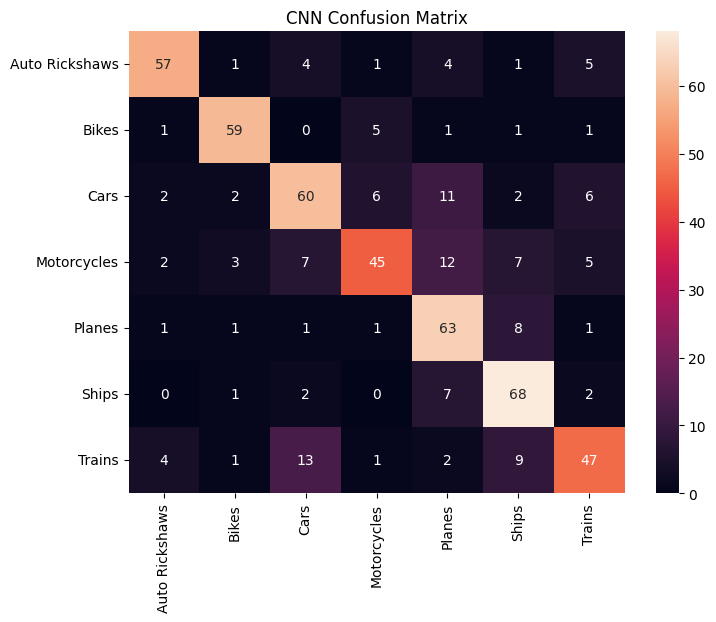

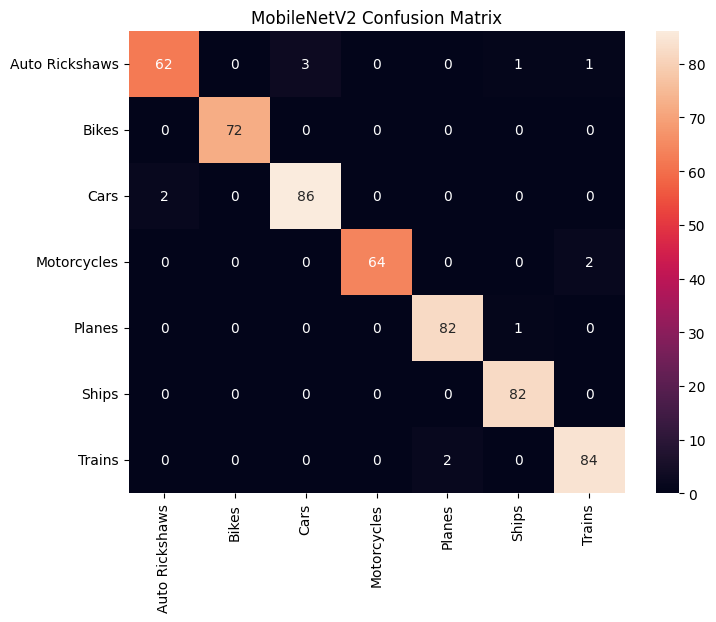

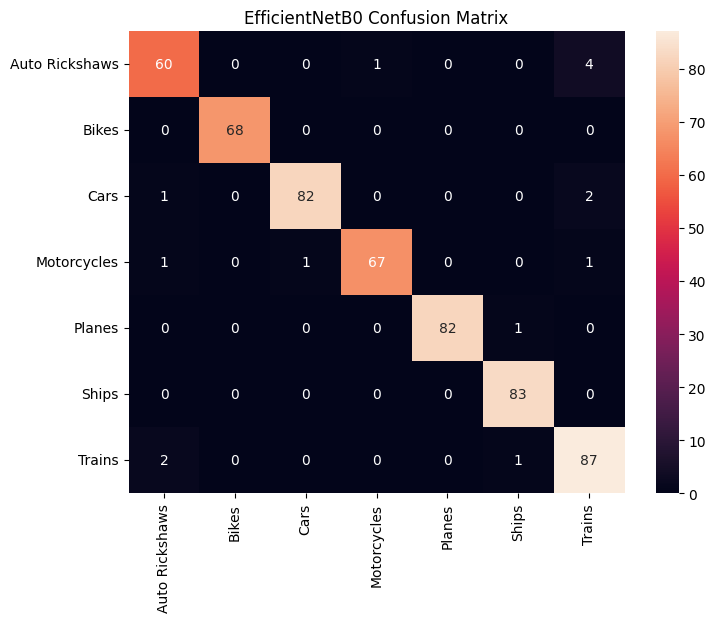

In [13]:

def evaluate_model(model,name):
    y_true=[]
    y_pred=[]

    for images,labels in test_ds:
        pred=model.predict(images,verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(pred,axis=1))

    acc=accuracy_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred,average='weighted')

    cm=confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True,fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'{name} Confusion Matrix')
    plt.savefig(f'/kaggle/working/{name}_confusion_matrix.pdf')
    plt.show()

    report=classification_report(y_true,y_pred,target_names=class_names,output_dict=True)
    pd.DataFrame(report).transpose().to_csv(
        f'/kaggle/working/{name}_classification_report.csv'
    )

    return acc,f1

cnn_acc,cnn_f1=evaluate_model(cnn,'CNN')
mobile_acc,mobile_f1=evaluate_model(mobilenet,'MobileNetV2')
eff_acc,eff_f1=evaluate_model(efficient,'EfficientNetB0')



In [14]:

comparison=pd.DataFrame({
    'Model':['CNN','MobileNetV2','EfficientNetB0'],
    'Accuracy':[cnn_acc,mobile_acc,eff_acc],
    'F1':[cnn_f1,mobile_f1,eff_f1]
})

comparison=comparison.sort_values('Accuracy',ascending=False)
comparison.to_csv('/kaggle/working/model_comparison.csv',index=False)
comparison


,Model,Accuracy,F1
1,MobileNetV2,0.977941,0.977857
2,EfficientNetB0,0.972426,0.972481
0,CNN,0.733456,0.731043


In [15]:
print("mobilenet:", 'mobilenet' in globals())
print("efficient:", 'efficient' in globals())
print("cnn:", 'cnn' in globals())

mobilenet: True
efficient: True
cnn: True


In [16]:
best_model = mobilenet

print(best_model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,284,887 (8.72 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 17,936 (70.07 KB)

None


In [17]:
base_model = best_model.layers[2]

print(base_model.name)

for layer in base_model.layers[-10:]:
    print(layer.name)

mobilenetv2_1.00_224
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


In [18]:
best_model = mobilenet

dummy = tf.random.normal((1,224,224,3))
_ = best_model(dummy)

print("Model ready")

Model ready


In [19]:
best_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,284,887 (8.72 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 17,936 (70.07 KB)

In [20]:
for i, layer in enumerate(best_model.layers):
    print(i, layer.name)

0 sequential
1 rescaling
2 mobilenetv2_1.00_224
3 global_average_pooling2d
4 dropout_1
5 dense_2


In [21]:
dummy = tf.random.normal((1,224,224,3))
_ = best_model(dummy)

In [22]:
best_model = mobilenet

dummy = tf.random.normal((1,224,224,3))
prediction = best_model(dummy)

print(prediction.shape)

(1, 7)


In [23]:
print(best_model.inputs)
print(best_model.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_173>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_179>]


In [24]:
best_model.save("mobilenet_gradcam.keras")

In [25]:
import tensorflow as tf

gradcam_model = tf.keras.models.load_model(
    "mobilenet_gradcam.keras"
)

print(gradcam_model.inputs)
print(gradcam_model.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_3>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_769>]


In [26]:
best_model.save("/kaggle/working/mobilenet_gradcam.keras")

In [27]:
reloaded = tf.keras.models.load_model(
    "/kaggle/working/mobilenet_gradcam.keras"
)

print(reloaded.inputs)
print(reloaded.outputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_3>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1112>]


In [28]:
for i, layer in enumerate(reloaded.layers):
    print(i, layer.name)

0 sequential
1 rescaling
2 mobilenetv2_1.00_224
3 global_average_pooling2d
4 dropout_1
5 dense_2


In [29]:
mobile_base = reloaded.layers[2]

for layer in mobile_base.layers[-10:]:
    print(layer.name)

block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


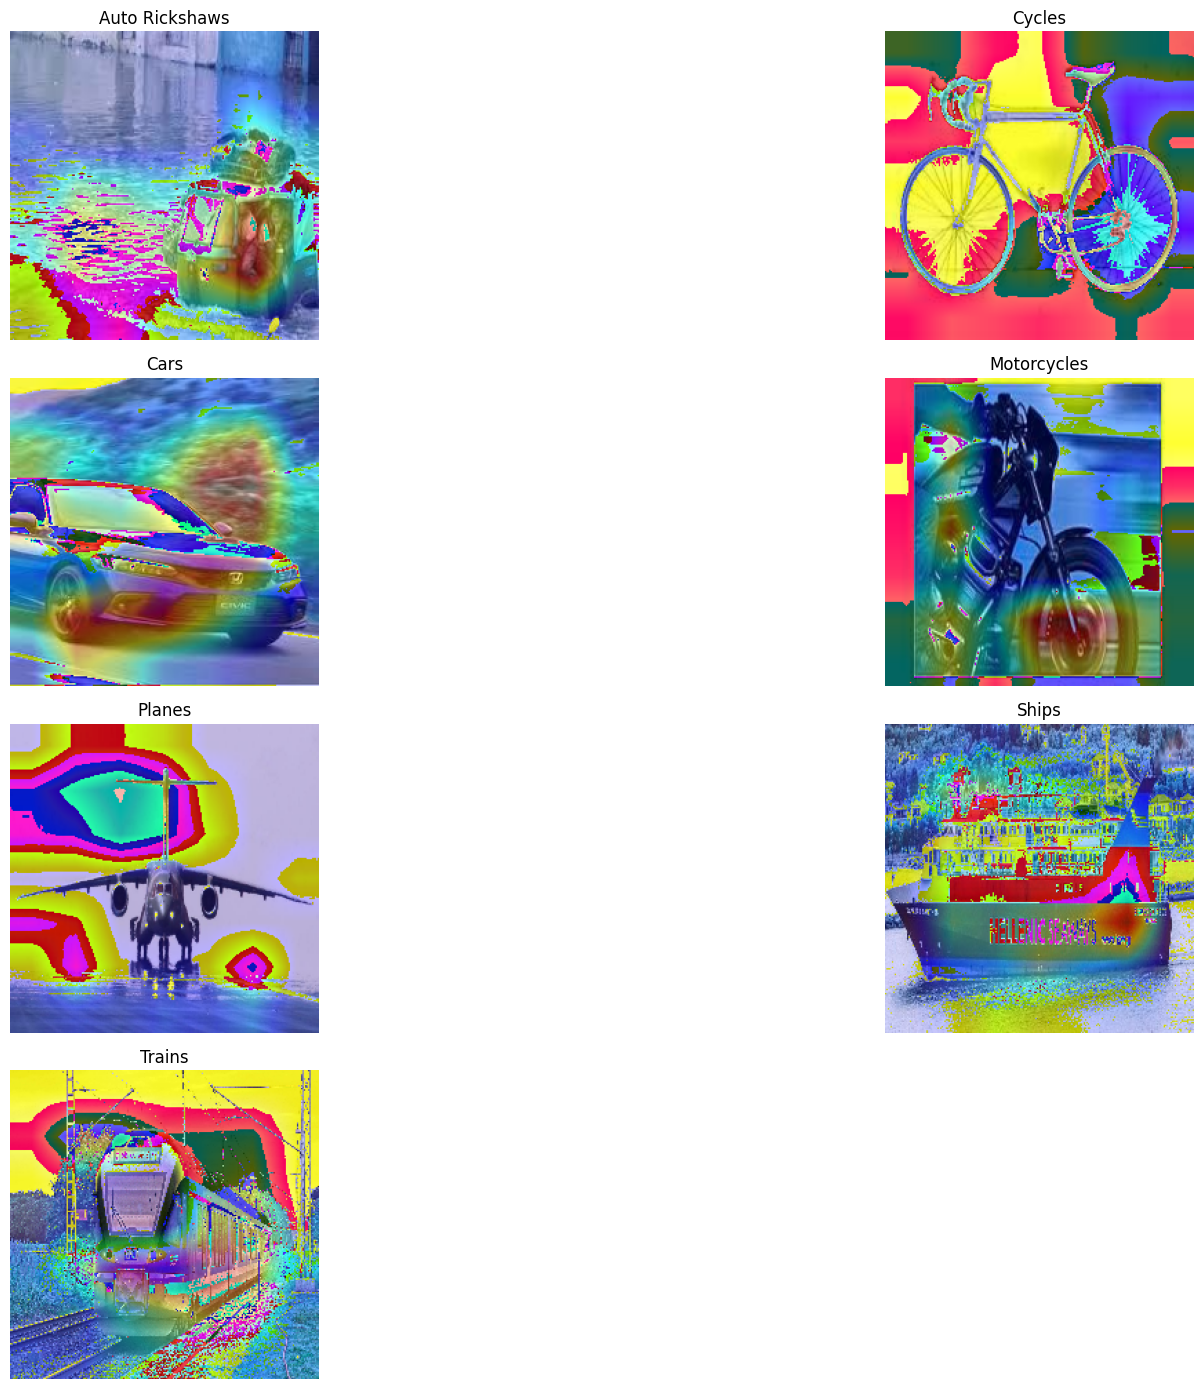

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

class_names = [
    "Auto Rickshaws",
    "Cycles",
    "Cars",
    "Motorcycles",
    "Planes",
    "Ships",
    "Trains"
]

mobile_base = reloaded.layers[2]

last_conv_layer = mobile_base.get_layer("out_relu")

feature_extractor = tf.keras.Model(
    mobile_base.input,
    last_conv_layer.output
)

classifier_input = tf.keras.Input(
    shape=last_conv_layer.output.shape[1:]
)

x = classifier_input
x = reloaded.layers[3](x)
x = reloaded.layers[4](x)
classifier_output = reloaded.layers[5](x)

classifier = tf.keras.Model(
    classifier_input,
    classifier_output
)

samples = {}

for images, labels in test_ds:

    for img, label in zip(images, labels):

        label = int(label.numpy())

        if label not in samples:
            samples[label] = img

        if len(samples) == len(class_names):
            break

    if len(samples) == len(class_names):
        break

plt.figure(figsize=(20,14))

for idx in range(len(class_names)):

    img = samples[idx]

    img_array = tf.expand_dims(
        img,
        axis=0
    )

    with tf.GradientTape() as tape:

        conv_outputs = feature_extractor(
            img_array
        )

        tape.watch(conv_outputs)

        predictions = classifier(
            conv_outputs
        )

        pred_index = tf.argmax(
            predictions[0]
        )

        loss = predictions[
            :, pred_index
        ]

    grads = tape.gradient(
        loss,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs_single = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs_single * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    heatmap = heatmap.numpy()

    img_np = img.numpy().astype(
        "uint8"
    )

    heatmap = cv2.resize(
        heatmap,
        (img_np.shape[1], img_np.shape[0])
    )

    heatmap = np.uint8(
        255 * heatmap
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed_img = (
        0.4 * heatmap + img_np
    )

    plt.subplot(
        4,
        2,
        idx + 1
    )

    plt.imshow(
        cv2.cvtColor(
            superimposed_img.astype("uint8"),
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        class_names[idx]
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/All_Classes_GradCAM.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

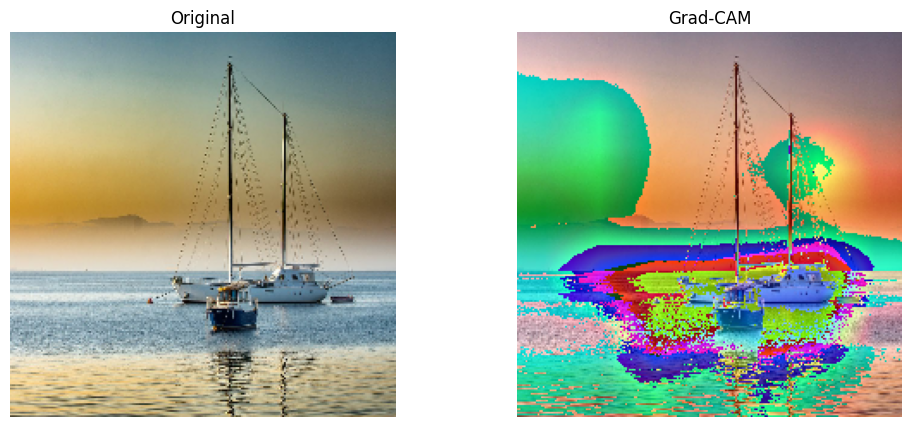

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Sample image
images, labels = next(iter(val_ds))
img = images[0]

img_array = tf.expand_dims(img, axis=0)

# MobileNetV2 backbone
mobile_base = reloaded.layers[2]

# Last convolution layer
last_conv_layer = mobile_base.get_layer("out_relu")

# Create a model for MobileNet features only
feature_extractor = tf.keras.Model(
    mobile_base.input,
    last_conv_layer.output
)

# Create classifier head manually
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

x = classifier_input
x = reloaded.layers[3](x)  # GlobalAveragePooling2D
x = reloaded.layers[4](x)  # Dropout
classifier_output = reloaded.layers[5](x)  # Dense

classifier = tf.keras.Model(
    classifier_input,
    classifier_output
)

with tf.GradientTape() as tape:

    conv_outputs = feature_extractor(img_array)

    tape.watch(conv_outputs)

    predictions = classifier(conv_outputs)

    pred_index = tf.argmax(predictions[0])

    loss = predictions[:, pred_index]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

heatmap /= (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()

# Overlay heatmap
img_np = img.numpy().astype("uint8")

heatmap = cv2.resize(
    heatmap,
    (img_np.shape[1], img_np.shape[0])
)

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = (
    0.4 * heatmap + img_np
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(superimposed_img.astype("uint8"))
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_173
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_173
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.92245].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5916157281026244e-09..1.949956640601158e-09].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.90709].
Clipping input data to the valid range for imsh

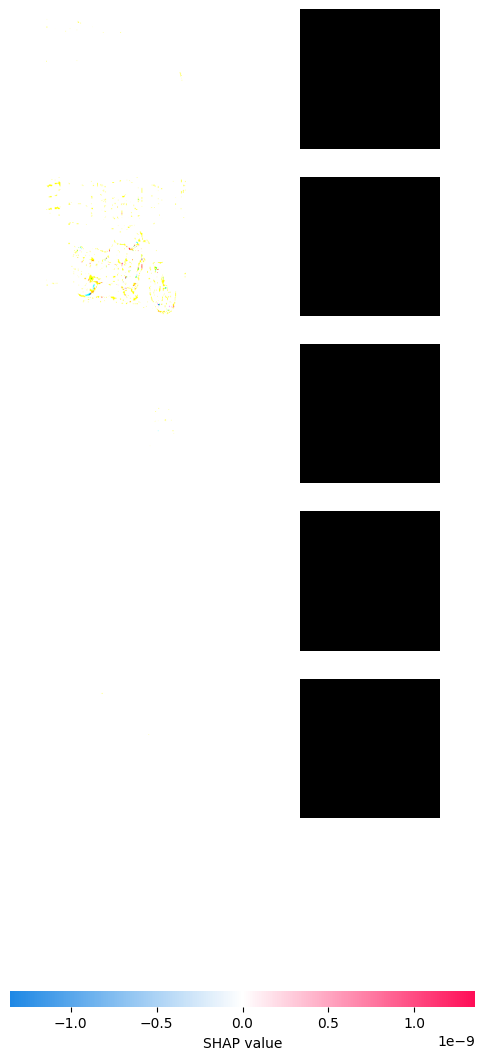

In [32]:

import shap
import numpy as np
import matplotlib.pyplot as plt

background = next(iter(train_ds))[0][:50].numpy()
sample_images = next(iter(test_ds))[0][:5].numpy()

explainer = shap.GradientExplainer(
    best_model,
    background
)

shap_values = explainer.shap_values(sample_images)

# Create SHAP plot
shap.image_plot(shap_values, sample_images, show=False)

# Save as PDF
plt.savefig(
    "/kaggle/working/SHAP_Explanation.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

last_conv_layer_name = "Conv_1"

In [34]:
best_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,284,887 (8.72 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 17,936 (70.07 KB)

In [35]:

# Save models
cnn.save('/kaggle/working/cnn_model.h5')
mobilenet.save('/kaggle/working/mobilenet_model.h5')
efficient.save('/kaggle/working/efficientnetb0_model.h5')


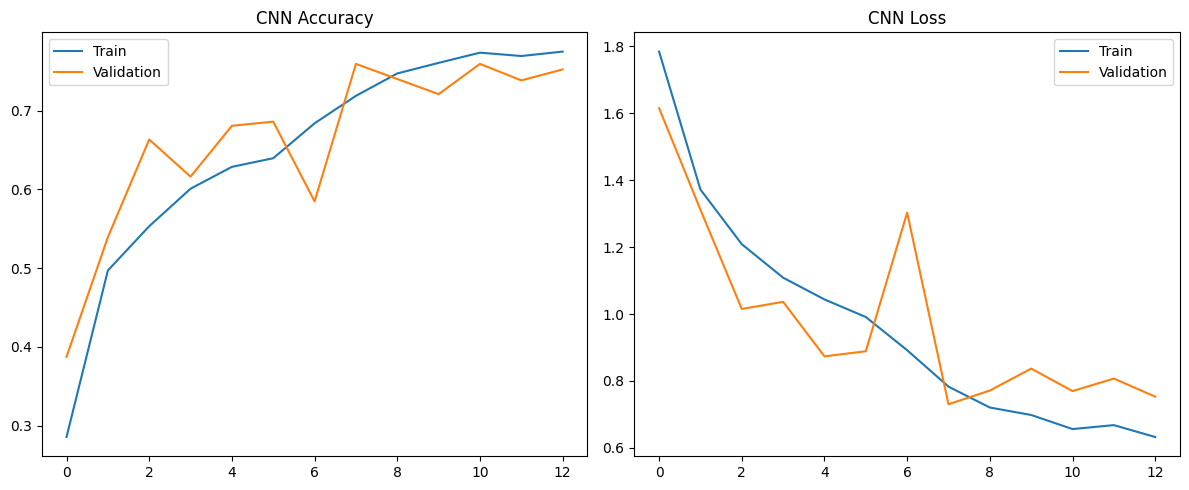

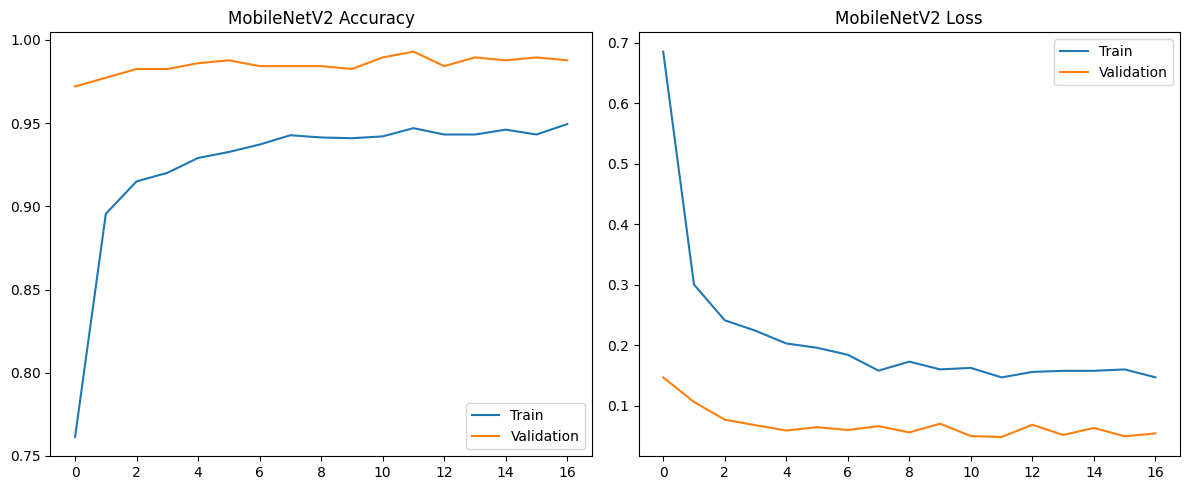

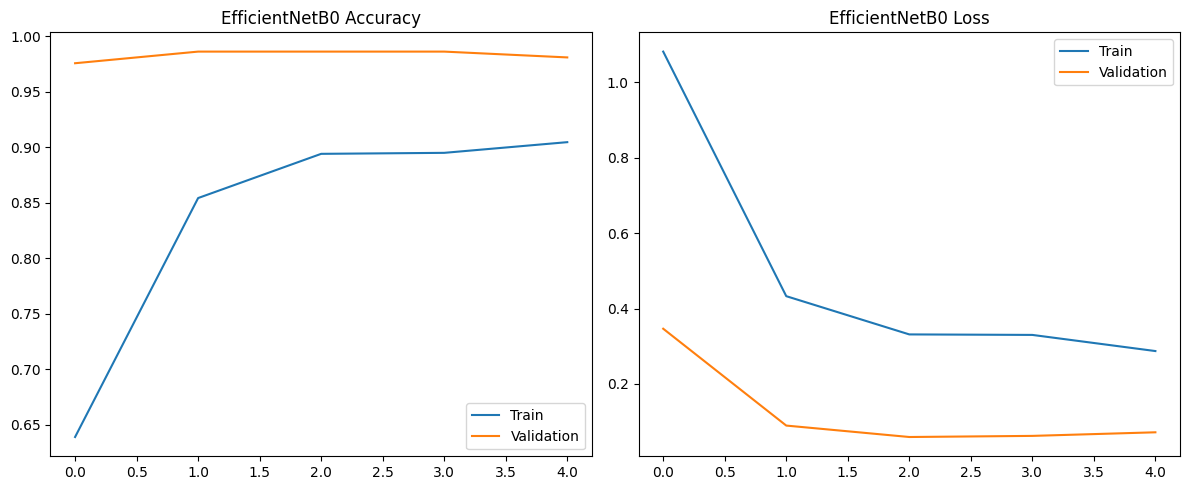

In [36]:
def plot_history(history, model_name):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.legend(['Train','Validation'])

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.legend(['Train','Validation'])

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_curves.pdf')
    plt.show()

plot_history(cnn_history, "CNN")
plot_history(mobile_history, "MobileNetV2")
plot_history(eff_history, "EfficientNetB0")

In [37]:
comparison.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

In [38]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

misclassified_idx = np.where(
    y_true != y_pred
)[0]

print("Misclassified:", len(misclassified_idx))

Misclassified: 9


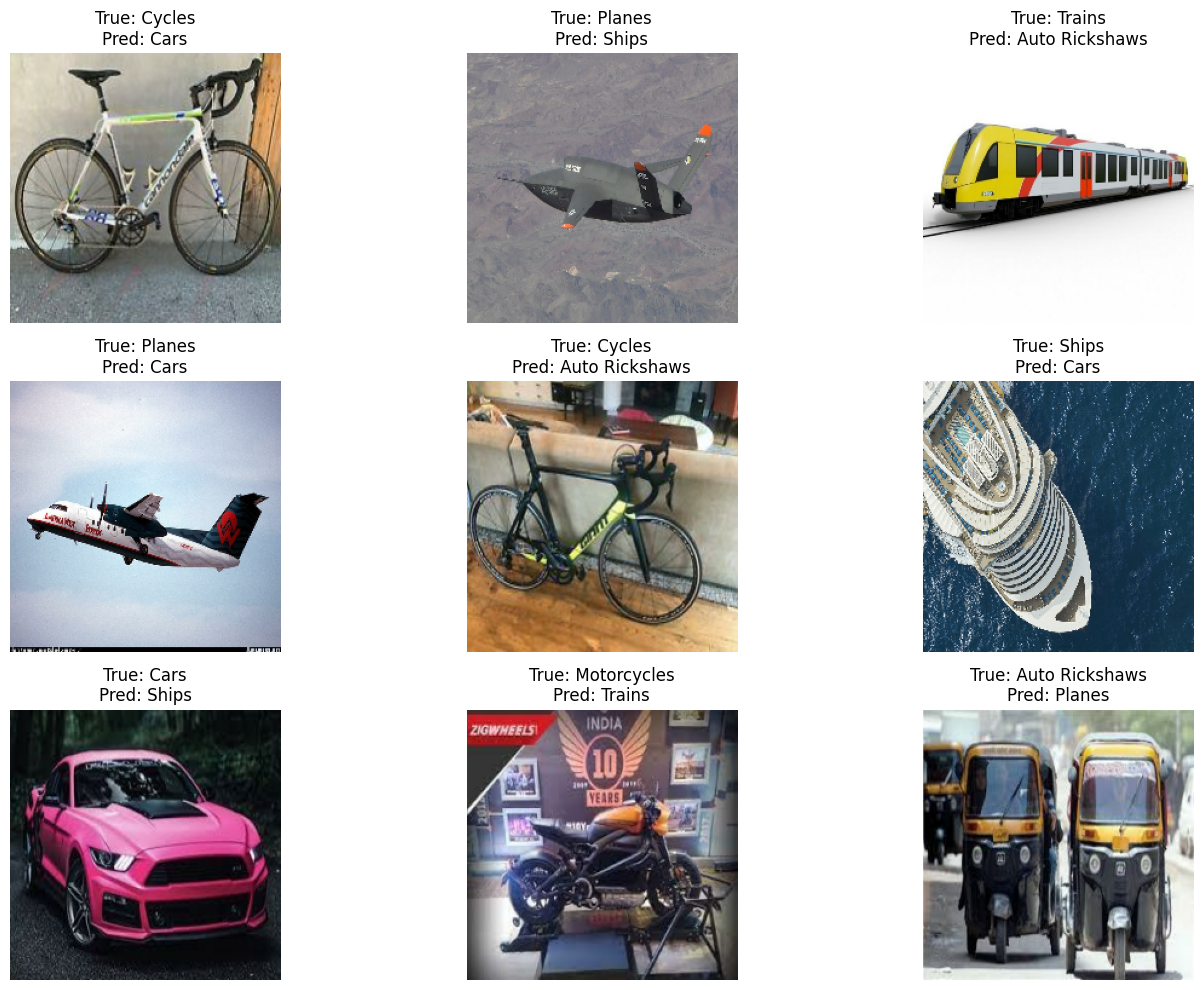

In [39]:
test_images = []
test_labels = []

for images, labels in test_ds:

    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified_idx[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(
        test_images[idx].astype("uint8")
    )

    plt.title(
        f"True: {class_names[test_labels[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/error_analysis.pdf"
)

plt.show()

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [41]:
y_true = []
y_prob = []

for images, labels in test_ds:

    preds = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(preds)

y_true = np.array(y_true)
y_prob = np.array(y_prob)

print(y_true.shape)
print(y_prob.shape)

(544,)
(544, 7)


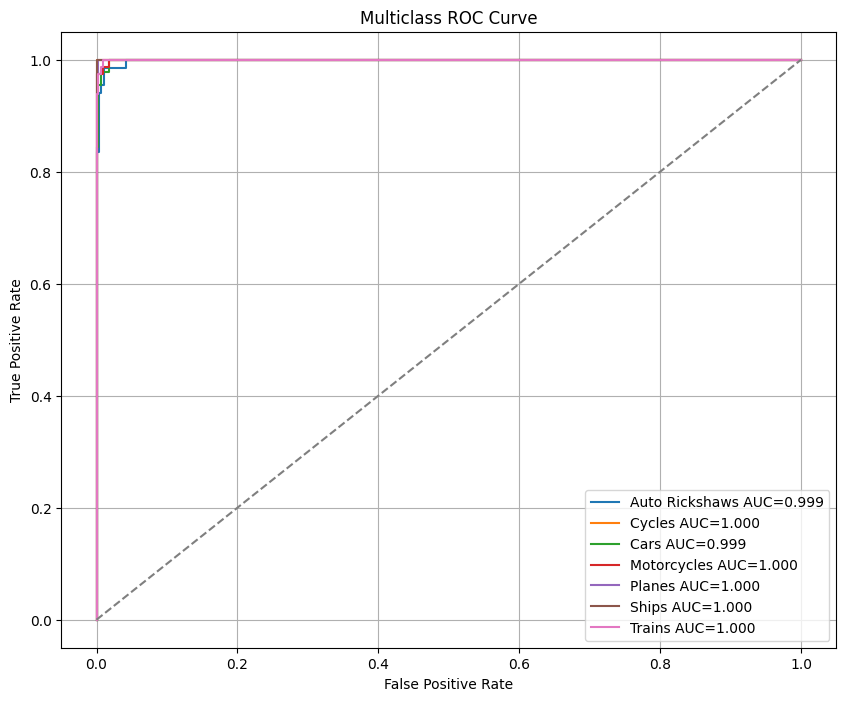

In [42]:
n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

plt.figure(figsize=(10,8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} AUC={roc_auc:.3f}'
    )

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curve"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "/kaggle/working/roc_curve.pdf"
)

plt.show()